### In this case swimmers initialized at (0,0) with n=(0,1). Velocity monotonic in I, no implementation of reorienting so far, in particular no I dependance in angular velocity. 

In [198]:
import numpy as np
from matplotlib import pyplot as plt

# import numba as nb

In [199]:
dim = 2

D_n = 0.5
D_r = 0. #TODO remove later
V0 = 1.

N_samples = 10**3
nt = 800    # number of times steps

dt = 10**-3
if not dt < 0.01 / D_n:
    raise Exception("too large time step")

# TODO consider applying similar criterion for D_r, what is the scale though (for angular its 2*np.pi)

In [200]:
r0 = np.zeros((dim, N_samples))
n0 = np.zeros((dim,N_samples))
n0[-1,:] = 1

r = r0 # initial position
n = n0 # initial orientation

In [201]:
# Tensor for saving positions
r_history = np.zeros((nt+1, dim, N_samples))
r_history[0,:,:] = r0

In [202]:
def I(r):   # (dim, sample)
    return np.exp(r[0,:])   # np.exp(x) for 2d, 3d

def V(I):
    return V0*np.ones_like(I)

zeta_n = np.random.normal(loc=0,scale=1,size = (nt, dim, N_samples)) # TODO rewrite in terms of vector perturabations
zeta_r = np.random.normal(loc=0,scale=1,size = (nt, dim, N_samples))

dn_rand = np.sqrt(2*D_n*dt)*zeta_n
dr_rand = np.sqrt(2*D_r*dt)*zeta_r


In [203]:
# n_test = np.ones((dim, N_samples))
# n_test /= np.linalg.norm(n_test, axis=0)


# n_current = n_test

In [204]:
for it in range(nt):
    r = n*V(I(r))*dt + r + dr_rand[it,:] #TODO I(r) needs to be modified
    n = (1-np.sum(n*dn_rand[it,:,:], axis=0))*n + dn_rand[it,:,:]
    n /= np.linalg.norm(n, axis=0)

    r_history[it+1,:,:] = r

    # n_new = (1-np.sum(n_current*dn_rand[it,:,:], axis=0))*n_current + dn_rand[it,:,:]
    # n_new /= np.linalg.norm(n_new, axis=0)

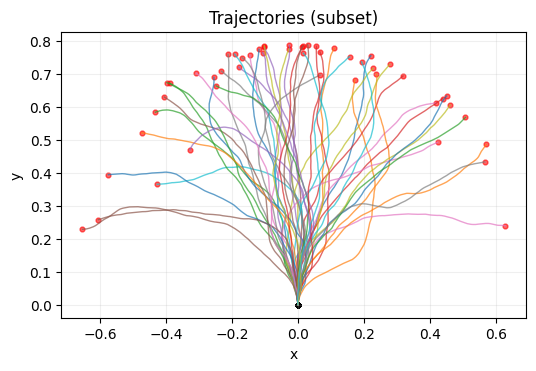

In [205]:
# Visualize trajectories in r_history
# r_history shape: (nt+1, dim, N_samples)

n_show = min(50, N_samples)           # number of trajectories to plot
idx = np.linspace(0, N_samples - 1, n_show, dtype=int)

t = np.arange(r_history.shape[0])

if dim == 2:
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in idx:
        ax.plot(r_history[:, 0, i], r_history[:, 1, i], lw=1, alpha=0.7)
        ax.scatter(r_history[0, 0, i], r_history[0, 1, i], s=10, c="k", alpha=0.6)
        ax.scatter(r_history[-1, 0, i], r_history[-1, 1, i], s=12, c="r", alpha=0.6)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Trajectories (subset)")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.2)
    plt.show()

elif dim == 3:
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    for i in idx:
        ax.plot(r_history[:, 0, i], r_history[:, 1, i], r_history[:, 2, i], lw=1, alpha=0.7)
        ax.scatter(r_history[0, 0, i], r_history[0, 1, i], r_history[0, 2, i], s=10, c="k", alpha=0.6)
        ax.scatter(r_history[-1, 0, i], r_history[-1, 1, i], r_history[-1, 2, i], s=12, c="r", alpha=0.6)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title("Trajectories (subset)")
    plt.show()


In [206]:
y_final = r_history[-1,0,:]
if_positive = y_final>0
if_negative = y_final<0
n_positive = np.sum(if_positive)
n_negative = np.sum(if_negative)
print(n_positive, n_negative)

496 504
